# mermaidx in Jupyter

`mermaidx` renders Mermaid diagrams without a browser, Node.js, or npm — and that includes right here in the notebook. This walks through everything: automatic inline display, PNG/PDF/ASCII export, themes, and the optional "live" mode that renders with the real mermaid.js in your browser.

```
pip install mermaidx
```


In [1]:
import mermaidx
import importlib
import mermaidx.engine
importlib.reload(mermaidx.engine)
mermaidx.__version__

'0.8.3'

## Automatic display

A `Diagram` shows up inline automatically when it's the last expression in a cell — no `.show()`, no `plt.figure()` boilerplate, just like a DataFrame or a matplotlib figure. This works because `Diagram` implements IPython's `_repr_svg_()` rich-display hook, and renders to a real, static SVG the first time it's needed (then caches it).

CPU times: user 15 μs, sys: 0 ns, total: 15 μs
Wall time: 16.7 μs


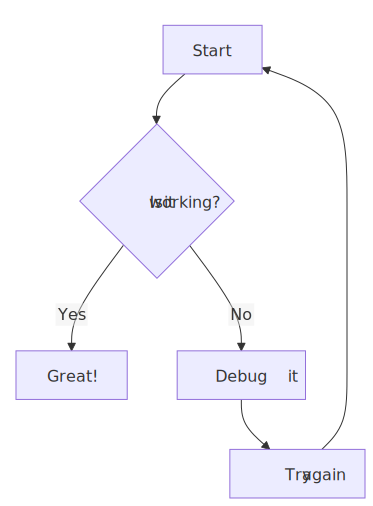

In [2]:
%%time
d = mermaidx.render("""
flowchart TD
    A[Start] --> B{Is it working?}
    B -->|Yes| C[Great!]
    B -->|No| D[Debug it]
    D --> E[Try again]
    E --> A
""", backend="quickjs")
d

path: 01_simple_flowchart.mmd
graph TD
    A[Input Code] --> B{Is Valid?}
    B -- Yes --> C(Render Output)
    B -- No --> D[Show Error]
    


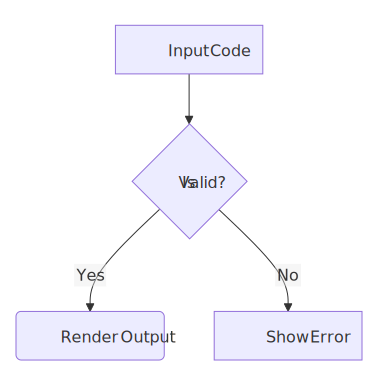

path: 02_data_flow.mmd
graph LR
    ID_1([API Request]) --> ID_2[[mermaidx Processing]]
    ID_2 --> ID_3[(Save SVG File)]



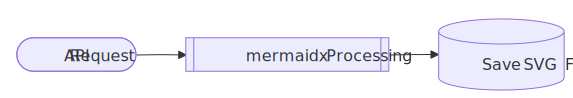

path: 03_simple_sequence.mmd
sequenceDiagram
    Client->>Server: HTTP POST /render
    Server-->>Client: 200 OK (SVG Data)



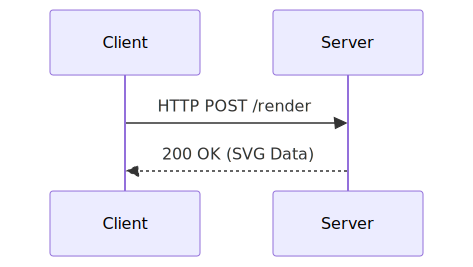

path: 04_simple_state.mmd
stateDiagram-v2
    [*] --> Off
    Off --> On : Press Switch
    On --> Off : Press Switch
    On --> [*]
    


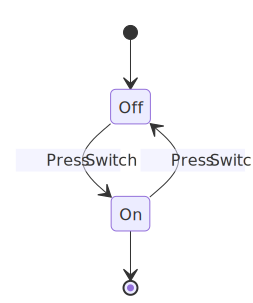

path: 05_simple_mindmap.mmd
mindmap
  root((mermaidx))
    Outputs
      SVG
      PNG
      ASCII
    Features
      Fast
      No Node
      


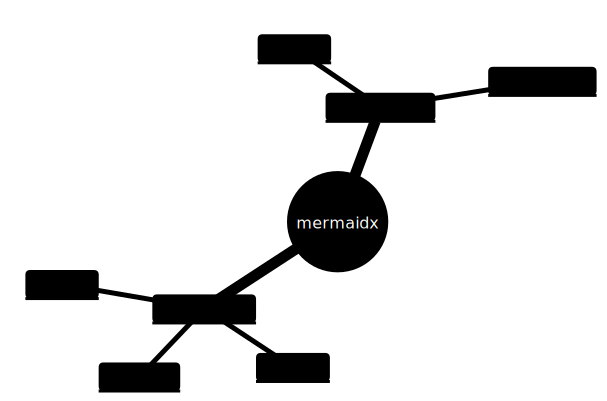

path: 06_complex_sequence.mmd
sequenceDiagram
    autonumber
    loop Every Second
        App->>Engine: Check Status
    end
    alt Engine is Free
        App->>Engine: Send Job
        Engine-->>App: Job Accepted
    else Engine is Busy
        Engine-->>App: Queue Full Error
    end
    


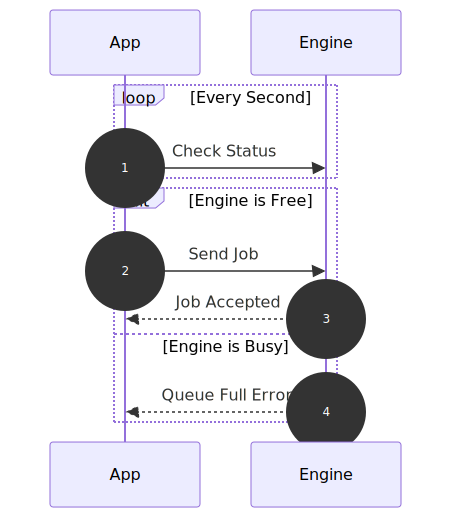

path: 07_complex_erd.mmd
erDiagram
    USER ||--o{ DIAGRAM : owns
    DIAGRAM ||--|{ RENDER_LOG : generates
    USER {
        int id PK
        string username
        string email
    }
    DIAGRAM {
        int id PK
        int user_id FK
        string raw_code
        string current_version
    }
    RENDER_LOG {
        int id PK
        int diagram_id FK
        string format
        datetime rendered_at
    }



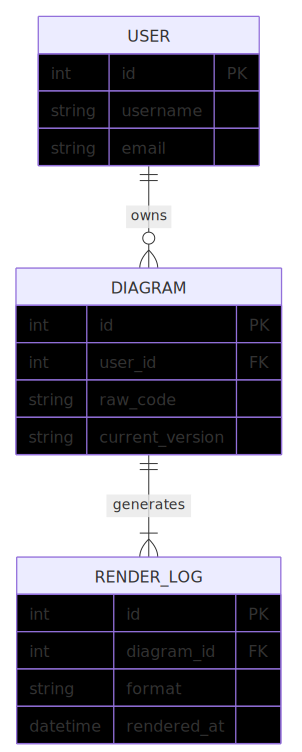

In [3]:
from pathlib import Path
for path in Path("../tests/samples/").glob("*.mmd"):
    print("path:", path.name)
    try:
        d = mermaidx.render(path.read_text(encoding="utf-8"), backend="quickjs")
        print(d._source)
        d.show()
    except:
        ...

        

## `.show()`

Useful when the diagram isn't the last line in the cell — e.g. inside a loop, or after some other output. Displays exactly what `.svg()` returns, so what you see is always this package's own render pipeline output -- not a separate re-render through some other engine.

default


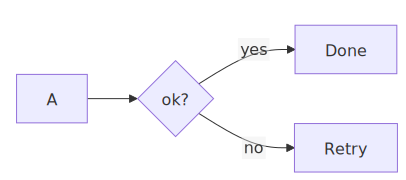

forest


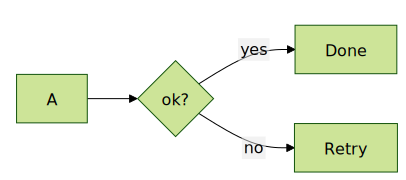

dark


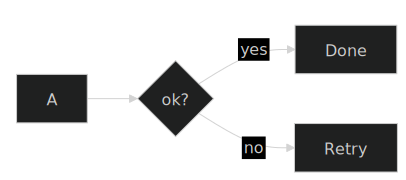

neutral


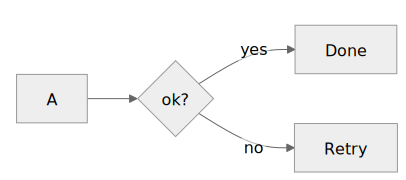

In [4]:
flowchart = "graph LR; A-->B{ok?}; B-->|yes|C[Done]; B-->|no|D[Retry]"

for theme in ["default", "forest", "dark", "neutral"]:
    print(theme)
    mermaidx.render(flowchart, theme=theme, backend="quickjs").show()

## PNG

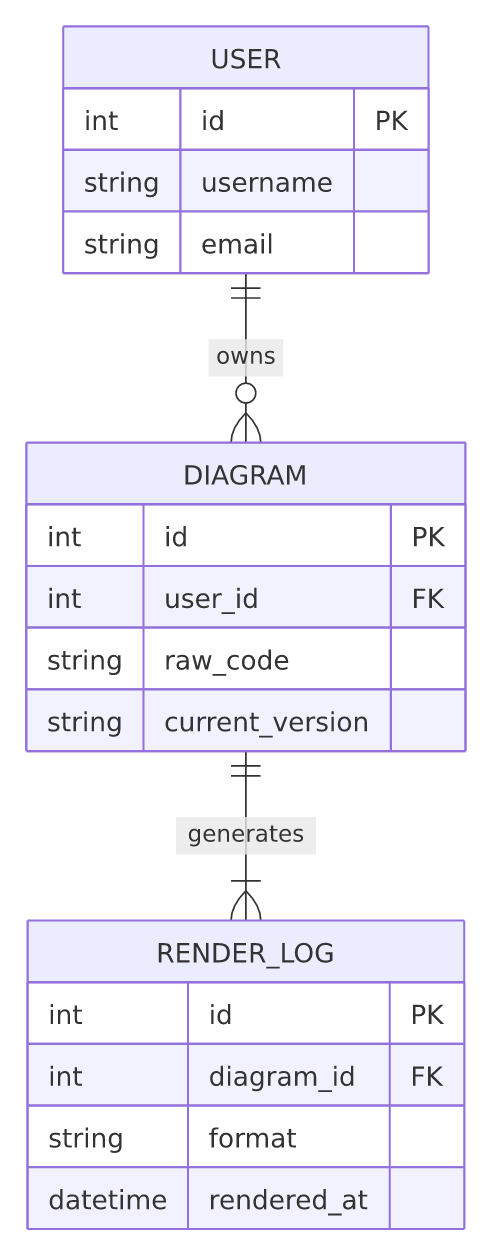

In [7]:
png_bytes = d.png(width=500, background="#ffffff")

from IPython.display import Image
Image(png_bytes)

## PDF, raw pixels, numpy, ASCII

All lazy, all cached — calling `.svg()` again after any of these doesn't re-render.

In [8]:
pdf_bytes = d.pdf(pdf_format="A4", pdf_margin="1cm")
print(f"PDF: {len(pdf_bytes):,} bytes")

raw, w, h = d.raw()
print(f"raw RGBA: {w}x{h}, {len(raw):,} bytes")

arr = d.numpy()  # needs numpy installed
print(f"numpy: {arr.shape} {arr.dtype}")

print(d.ascii())

PDF: 19,075 bytes
raw RGBA: 303x753, 912,636 bytes
numpy: (753, 303, 4) uint8


     ┌─────────────────┐
     │      USER       │
     ├─────────────────┤
     │ int id  PK      │
     │ string username │
     │ string email    │
     └─────────────────┘
              │1
              └┐owns
               │
               │0..*
  ┌────────────────────────┐
  │        DIAGRAM         │
  ├────────────────────────┤
  │ int id  PK             │
  │ int user_id  FK        │
  │ string raw_code        │
  │ string current_version │
  └────────────────────────┘
               │1
               │ generates
               │
               │1..*
   ┌──────────────────────┐
   │      RENDER_LOG      │
   ├──────────────────────┤
   │ int id  PK           │
   │ int diagram_id  FK   │
   │ string format        │
   │ datetime rendered_at │
   └──────────────────────┘


## Saving to disk

Format is inferred from the extension, or forced with `format=`.

In [9]:
d.save("diagram.svg")
d.save("diagram.png", width=1200)
d.save("diagram.pdf", pdf_format="A4")
d.save("diagram.txt")                     # ASCII, from the .txt extension
d.save("diagram.backup", format="png")   # forced, ignoring the odd extension

## Backends

`'js'` (mermaidx's own engine) is always available. If the optional [`mmdr`](https://github.com/mohammadraziei/mmdr) package is installed, its backends show up too, and PDF/raw/numpy work for them the same way — mermaidx supplies those from its own resvg pipeline even for backends that don't natively support them.

In [10]:
mermaidx.backends()

['quickjs', 'v8', 'merman', 'mermaid-rs-renderer']

## Batch rendering

CPU-bound work parallelizes with real processes, not `async` — each worker starts its own engine once and reuses it for every diagram routed to it.

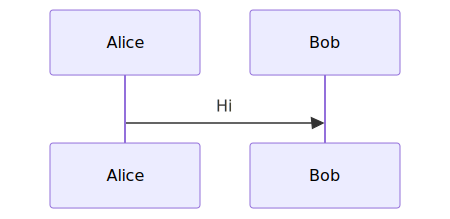

In [11]:
sources = [
    "graph LR; A-->B",
    "sequenceDiagram\n  Alice->>Bob: Hi",
    "stateDiagram-v2\n  [*] --> Idle\n  Idle --> Running",
]

diagrams = mermaidx.render_many(sources, workers=2)
diagrams[1]